Tự xây công thức - Bottom up single linkage

Kết quả phân cụm Hierarchical (Bottom-up, Single Linkage)

Bảng chỉ số Silhouette cho các giá trị k:
----------------------------------------
k (Số cụm)      Silhouette Score    
----------------------------------------
2               0.8108               *** TỐI ƯU ***
3               0.6406              
4               0.4809              
5               0.4510              
6               0.4064              
7               0.3362              
8               0.2993              
9               0.2364              
10              0.2302              
----------------------------------------

KẾT QUẢ TỐI ƯU:
Số cụm tối ưu (k):           2
Chỉ số Silhouette tối ưu:    0.8108


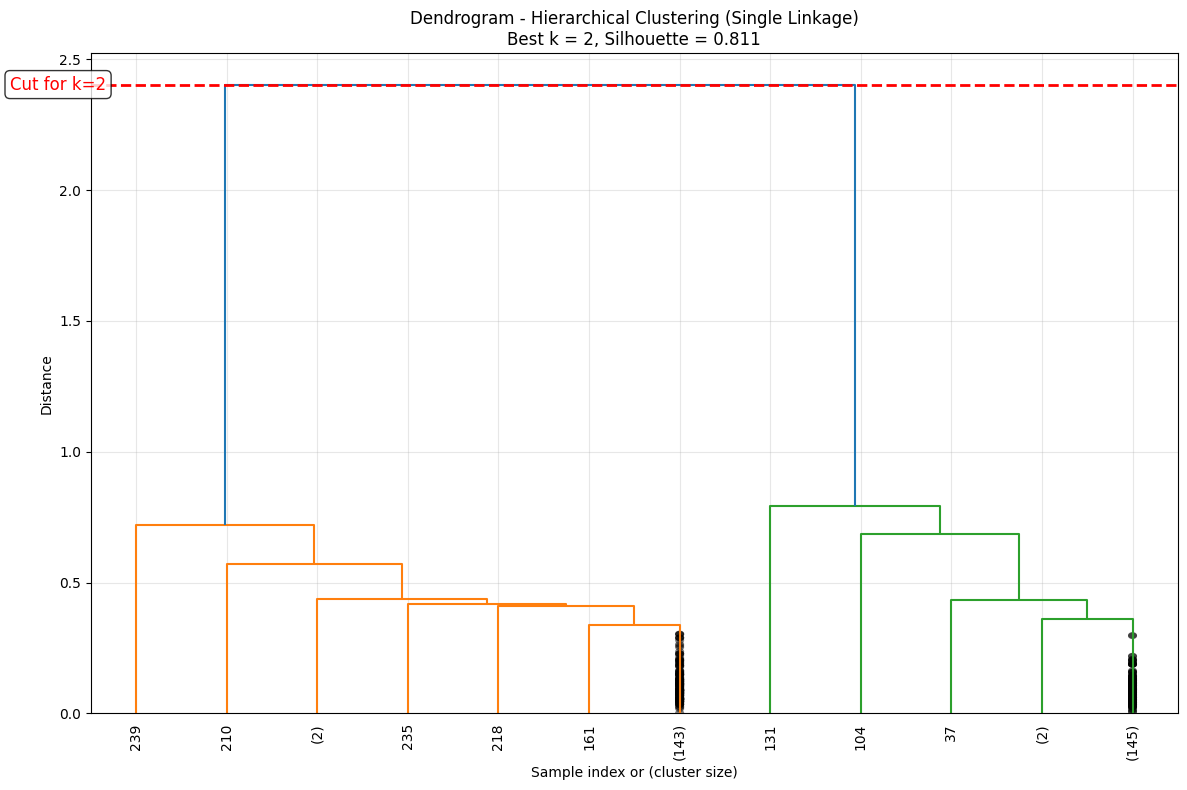

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

df = pd.read_csv("data_sample.csv")
X = df.values
n = len(X)

clusters = [[i] for i in range(n)]

dist_matrix = np.full((n, n), np.inf)
for i in range(n):
    for j in range(i+1, n):
        dist = np.sqrt(np.sum((X[i] - X[j]) ** 2))
        dist_matrix[i, j] = dist
        dist_matrix[j, i] = dist
np.fill_diagonal(dist_matrix, 0)

def single_linkage_dist(cluster_a, cluster_b):
    min_dist = np.inf
    for i in cluster_a:
        for j in cluster_b:
            if dist_matrix[i, j] < min_dist:
                min_dist = dist_matrix[i, j]
    return min_dist

def silhouette_score_custom(X, cluster_labels):
    n = len(X)
    unique_labels = np.unique(cluster_labels)
    if len(unique_labels) <= 1:
        return -1

    scores = []
    for i in range(n):
        same_cluster = cluster_labels == cluster_labels[i]
        same_points = np.where(same_cluster)[0]
        same_points = same_points[same_points != i]

        if len(same_points) > 0:
            a_i = np.mean([np.sqrt(np.sum((X[i] - X[j]) ** 2)) for j in same_points])
        else:
            a_i = 0

        b_i = np.inf
        for label in unique_labels:
            if label == cluster_labels[i]:
                continue
            other_points = np.where(cluster_labels == label)[0]
            if len(other_points) > 0:
                avg_dist = np.mean([np.sqrt(np.sum((X[i] - X[j]) ** 2)) for j in other_points])
                b_i = min(b_i, avg_dist)

        if max(a_i, b_i) > 0:
            s_i = (b_i - a_i) / max(a_i, b_i)
        else:
            s_i = 0
        scores.append(s_i)

    return np.mean(scores)

def clusters_to_labels(clusters, n):
    labels = np.zeros(n, dtype=int)
    for idx, cluster in enumerate(clusters):
        for point in cluster:
            labels[point] = idx
    return labels

linkage_matrix = []
cluster_history = []
clusters = [[i] for i in range(n)]
next_cluster_id = n

cluster_id_map = {i: i for i in range(n)}

while len(clusters) > 1:
    min_dist = np.inf
    merge_i, merge_j = -1, -1

    for i in range(len(clusters)):
        for j in range(i+1, len(clusters)):
            dist = single_linkage_dist(clusters[i], clusters[j])
            if dist < min_dist:
                min_dist = dist
                merge_i, merge_j = i, j

    id_i = cluster_id_map[merge_i]
    id_j = cluster_id_map[merge_j]

    new_cluster = clusters[merge_i] + clusters[merge_j]

    linkage_matrix.append([
        min(id_i, id_j),
        max(id_i, id_j),
        min_dist,
        len(new_cluster)
    ])

    clusters[merge_i] = new_cluster
    cluster_id_map[merge_i] = next_cluster_id
    next_cluster_id += 1

    clusters.pop(merge_j)
    new_map = {}
    for new_idx, old_idx in enumerate(range(len(clusters))):
        if new_idx < merge_j:
            new_map[new_idx] = cluster_id_map[old_idx]
        else:
            new_map[new_idx] = cluster_id_map[old_idx + 1]
    cluster_id_map = new_map

best_k = -1
best_score = -1
best_labels = None

k_silhouette_scores = {}

clusters = [[i] for i in range(n)]

while len(clusters) > 1:
    current_k = len(clusters)

    if 2 <= current_k <= 10:
        labels = clusters_to_labels(clusters, n)
        score = silhouette_score_custom(X, labels)

        k_silhouette_scores[current_k] = score

        if score > best_score:
            best_score = score
            best_k = current_k
            best_labels = labels.copy()

    if len(clusters) == 1:
        break

    min_dist = np.inf
    merge_i, merge_j = -1, -1

    for i in range(len(clusters)):
        for j in range(i+1, len(clusters)):
            dist = single_linkage_dist(clusters[i], clusters[j])
            if dist < min_dist:
                min_dist = dist
                merge_i, merge_j = i, j

    new_cluster = clusters[merge_i] + clusters[merge_j]
    clusters[merge_i] = new_cluster
    clusters.pop(merge_j)

print("=" * 60)
print("Kết quả phân cụm Hierarchical (Bottom-up, Single Linkage)")
print("=" * 60)

print("\nBảng chỉ số Silhouette cho các giá trị k:")
print("-" * 40)
print(f"{'k (Số cụm)':<15} {'Silhouette Score':<20}")
print("-" * 40)

for k in sorted(k_silhouette_scores.keys()):
    score = k_silhouette_scores[k]
    if k == best_k:
        print(f"{k:<15} {score:<20.4f} *** TỐI ƯU ***")
    else:
        print(f"{k:<15} {score:<20.4f}")

print("-" * 40)

print("\n" + "=" * 60)
print("KẾT QUẢ TỐI ƯU:")
print("=" * 60)
print(f"Số cụm tối ưu (k):           {best_k}")
print(f"Chỉ số Silhouette tối ưu:    {best_score:.4f}")
print("=" * 60)

plt.figure(figsize=(12, 8))
Z = np.array(linkage_matrix)

dendrogram(Z,
           truncate_mode='lastp',
           p=12,
           show_leaf_counts=True,
           leaf_rotation=90,
           leaf_font_size=10,
           show_contracted=True)

plt.axhline(y=Z[-best_k+1, 2], color='r', linestyle='--', linewidth=2)
plt.text(Z[-1, 2]*0.7, Z[-best_k+1, 2], f'Cut for k={best_k}',
         color='r', fontsize=12, va='center', ha='right',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.title(f'Dendrogram - Hierarchical Clustering (Single Linkage)\nBest k = {best_k}, Silhouette = {best_score:.3f}')
plt.xlabel('Sample index or (cluster size)')
plt.ylabel('Distance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Tự xây công thức - Bottom up complete linkage

Kết quả phân cụm Hierarchical (Bottom-up, Complete Linkage)

Bảng chỉ số Silhouette cho các giá trị k:
----------------------------------------
k (Số cụm)      Silhouette Score    
----------------------------------------
2               0.8108               *** TỐI ƯU ***
3               0.5450              
4               0.2898              
5               0.3071              
6               0.2830              
7               0.2803              
8               0.3070              
9               0.2920              
10              0.2841              
----------------------------------------

KẾT QUẢ TỐI ƯU:
Số cụm tối ưu (k):           2
Chỉ số Silhouette tối ưu:    0.8108


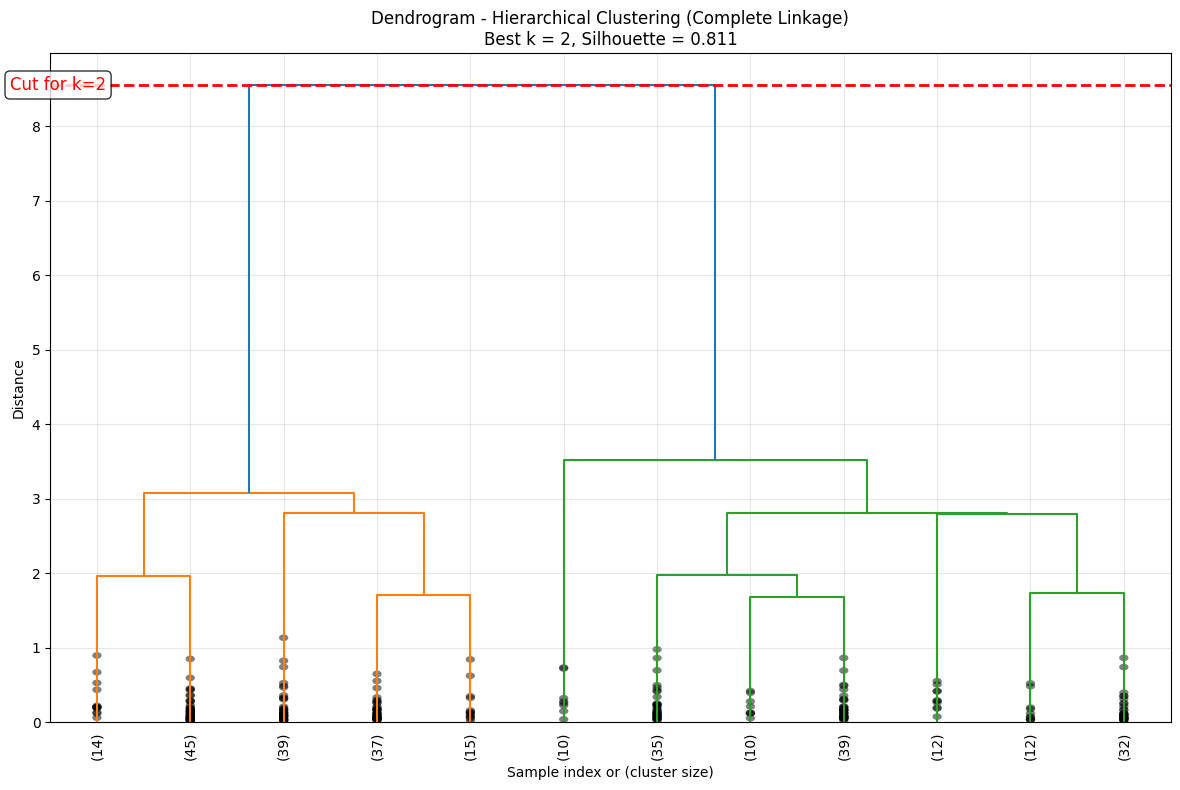

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

df = pd.read_csv("data_sample.csv")
X = df.values
n = len(X)

clusters = [[i] for i in range(n)]

dist_matrix = np.full((n, n), np.inf)
for i in range(n):
    for j in range(i+1, n):
        dist = np.sqrt(np.sum((X[i] - X[j]) ** 2))
        dist_matrix[i, j] = dist
        dist_matrix[j, i] = dist
np.fill_diagonal(dist_matrix, 0)

def complete_linkage_dist(cluster_a, cluster_b):
    max_dist = -np.inf
    for i in cluster_a:
        for j in cluster_b:
            if dist_matrix[i, j] > max_dist:
                max_dist = dist_matrix[i, j]
    return max_dist

def silhouette_score_custom(X, cluster_labels):
    n = len(X)
    unique_labels = np.unique(cluster_labels)
    if len(unique_labels) <= 1:
        return -1

    scores = []
    for i in range(n):
        same_cluster = cluster_labels == cluster_labels[i]
        same_points = np.where(same_cluster)[0]
        same_points = same_points[same_points != i]

        if len(same_points) > 0:
            a_i = np.mean([np.sqrt(np.sum((X[i] - X[j]) ** 2)) for j in same_points])
        else:
            a_i = 0

        b_i = np.inf
        for label in unique_labels:
            if label == cluster_labels[i]:
                continue
            other_points = np.where(cluster_labels == label)[0]
            if len(other_points) > 0:
                avg_dist = np.mean([np.sqrt(np.sum((X[i] - X[j]) ** 2)) for j in other_points])
                b_i = min(b_i, avg_dist)

        if max(a_i, b_i) > 0:
            s_i = (b_i - a_i) / max(a_i, b_i)
        else:
            s_i = 0
        scores.append(s_i)

    return np.mean(scores)

def clusters_to_labels(clusters, n):
    labels = np.zeros(n, dtype=int)
    for idx, cluster in enumerate(clusters):
        for point in cluster:
            labels[point] = idx
    return labels

linkage_matrix = []
cluster_history = []
clusters = [[i] for i in range(n)]
next_cluster_id = n

cluster_id_map = {i: i for i in range(n)}

while len(clusters) > 1:
    min_dist = np.inf
    merge_i, merge_j = -1, -1

    for i in range(len(clusters)):
        for j in range(i+1, len(clusters)):
            dist = complete_linkage_dist(clusters[i], clusters[j])
            if dist < min_dist:
                min_dist = dist
                merge_i, merge_j = i, j

    id_i = cluster_id_map[merge_i]
    id_j = cluster_id_map[merge_j]

    new_cluster = clusters[merge_i] + clusters[merge_j]

    linkage_matrix.append([
        min(id_i, id_j),
        max(id_i, id_j),
        min_dist,
        len(new_cluster)
    ])

    clusters[merge_i] = new_cluster
    cluster_id_map[merge_i] = next_cluster_id
    next_cluster_id += 1

    clusters.pop(merge_j)
    new_map = {}
    for new_idx, old_idx in enumerate(range(len(clusters))):
        if new_idx < merge_j:
            new_map[new_idx] = cluster_id_map[old_idx]
        else:
            new_map[new_idx] = cluster_id_map[old_idx + 1]
    cluster_id_map = new_map

best_k = -1
best_score = -1
best_labels = None

k_silhouette_scores = {}

clusters = [[i] for i in range(n)]

while len(clusters) > 1:
    current_k = len(clusters)

    if 2 <= current_k <= 10:
        labels = clusters_to_labels(clusters, n)
        score = silhouette_score_custom(X, labels)

        k_silhouette_scores[current_k] = score

        if score > best_score:
            best_score = score
            best_k = current_k
            best_labels = labels.copy()

    if len(clusters) == 1:
        break

    min_dist = np.inf
    merge_i, merge_j = -1, -1

    for i in range(len(clusters)):
        for j in range(i+1, len(clusters)):
            dist = complete_linkage_dist(clusters[i], clusters[j])
            if dist < min_dist:
                min_dist = dist
                merge_i, merge_j = i, j

    new_cluster = clusters[merge_i] + clusters[merge_j]
    clusters[merge_i] = new_cluster
    clusters.pop(merge_j)

print("=" * 60)
print("Kết quả phân cụm Hierarchical (Bottom-up, Complete Linkage)")
print("=" * 60)

print("\nBảng chỉ số Silhouette cho các giá trị k:")
print("-" * 40)
print(f"{'k (Số cụm)':<15} {'Silhouette Score':<20}")
print("-" * 40)

for k in sorted(k_silhouette_scores.keys()):
    score = k_silhouette_scores[k]
    if k == best_k:
        print(f"{k:<15} {score:<20.4f} *** TỐI ƯU ***")
    else:
        print(f"{k:<15} {score:<20.4f}")

print("-" * 40)

print("\n" + "=" * 60)
print("KẾT QUẢ TỐI ƯU:")
print("=" * 60)
print(f"Số cụm tối ưu (k):           {best_k}")
print(f"Chỉ số Silhouette tối ưu:    {best_score:.4f}")
print("=" * 60)
plt.figure(figsize=(12, 8))
Z = np.array(linkage_matrix)

dendrogram(Z,
           truncate_mode='lastp',
           p=12,
           show_leaf_counts=True,
           leaf_rotation=90,
           leaf_font_size=10,
           show_contracted=True)

plt.axhline(y=Z[-best_k+1, 2], color='r', linestyle='--', linewidth=2)
plt.text(Z[-1, 2]*0.7, Z[-best_k+1, 2], f'Cut for k={best_k}',
         color='r', fontsize=12, va='center', ha='right',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.title(f'Dendrogram - Hierarchical Clustering (Complete Linkage)\nBest k = {best_k}, Silhouette = {best_score:.3f}')
plt.xlabel('Sample index or (cluster size)')
plt.ylabel('Distance')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Sử dụng thư viện - Bottom up

BOTTOM-UP (Agglomerative - Single Linkage)
k=2, silhouette=0.8108  *** BEST ***
k=3, silhouette=0.6373
k=4, silhouette=0.4742
k=5, silhouette=0.4410
k=6, silhouette=0.3931
k=7, silhouette=0.3228
k=8, silhouette=0.2827
k=9, silhouette=0.2164
k=10, silhouette=0.2068

Best k = 2, best silhouette = 0.8108


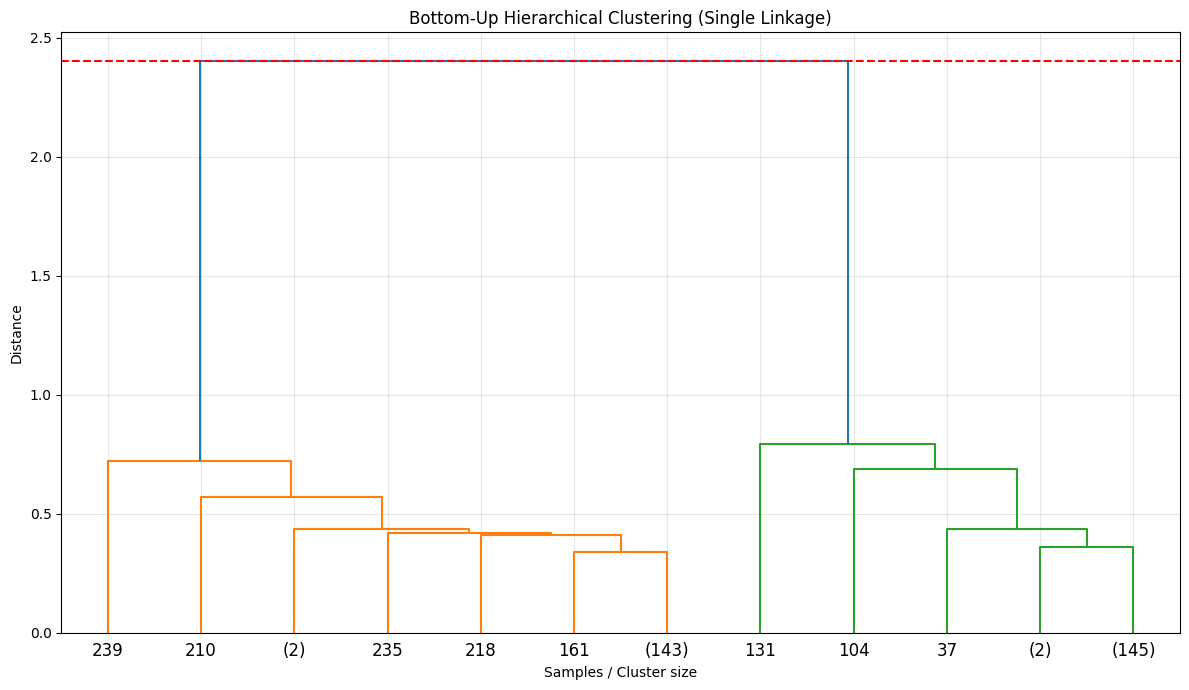

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

df = pd.read_csv("data_sample.csv")
X = df.values
best_k = -1
best_score = -1
scores = {}

for k in range(2, 11):
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage='single',
        metric='euclidean'
    )
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)

    scores[k] = score
    if score > best_score:
        best_k = k
        best_score = score

print("BOTTOM-UP (Agglomerative - Single Linkage)")
for k, s in scores.items():
    if k == best_k:
        print(f"k={k}, silhouette={s:.4f}  *** BEST ***")
    else:
        print(f"k={k}, silhouette={s:.4f}")

print(f"\nBest k = {best_k}, best silhouette = {best_score:.4f}")
Z = linkage(X, method='single')
plt.figure(figsize=(12, 7))
dendrogram(
    Z,
    truncate_mode='lastp',
    p=12,
    show_leaf_counts=True
)
plt.axhline(y=Z[-best_k + 1, 2], color='r', linestyle='--')
plt.title("Bottom-Up Hierarchical Clustering (Single Linkage)")
plt.xlabel("Samples / Cluster size")
plt.ylabel("Distance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
